**Все представленные материалы взяты из открытых источников в интернете плюс искусственный интеллект.**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import torch.optim as optim

from sklearn.datasets import fetch_california_housing
from torch import nn
from tqdm.notebook import tqdm

%matplotlib inline

In [2]:
arr = np.random.rand(5, 3)
arr

array([[0.38772702, 0.39695912, 0.77260239],
       [0.74945415, 0.01727325, 0.43376177],
       [0.68937864, 0.49339441, 0.4425646 ],
       [0.22351163, 0.75805557, 0.16844416],
       [0.27523739, 0.54603341, 0.22260378]])

In [3]:
arr.shape

(5, 3)

In [4]:
arr + 5

array([[5.38772702, 5.39695912, 5.77260239],
       [5.74945415, 5.01727325, 5.43376177],
       [5.68937864, 5.49339441, 5.4425646 ],
       [5.22351163, 5.75805557, 5.16844416],
       [5.27523739, 5.54603341, 5.22260378]])

In [5]:
arr @ arr.T

array([[0.90482324, 0.63256578, 0.8050746 , 0.51771893, 0.49545412],
       [0.63256578, 0.75012916, 0.71714781, 0.25367044, 0.31226659],
       [0.8050746 , 0.71714781, 0.91454438, 0.60265194, 0.55766916],
       [0.51771893, 0.25367044, 0.60265194, 0.65297912, 0.51293873],
       [0.49545412, 0.31226659, 0.55766916, 0.51293873, 0.42346055]])

In [6]:
arr.mean(axis=-1)

array([0.51909618, 0.40016306, 0.54177922, 0.38333712, 0.34795819])

In [7]:
arr.reshape(3, 5).shape

(3, 5)

In [8]:
x = torch.rand(5, 3)
x

tensor([[0.6109, 0.3579, 0.5978],
        [0.4188, 0.6819, 0.7937],
        [0.8992, 0.7455, 0.6968],
        [0.0028, 0.0562, 0.3609],
        [0.9960, 0.3106, 0.3599]])

In [9]:
x.shape

torch.Size([5, 3])

In [10]:
x.size()

torch.Size([5, 3])

In [11]:
x + 5

tensor([[5.6109, 5.3579, 5.5978],
        [5.4188, 5.6819, 5.7937],
        [5.8992, 5.7455, 5.6968],
        [5.0028, 5.0562, 5.3609],
        [5.9960, 5.3106, 5.3599]])

In [12]:
torch.matmul(x, x.transpose(1, 0))

tensor([[0.8587, 0.9744, 1.2327, 0.2376, 0.9348],
        [0.9744, 1.2704, 1.4380, 0.3260, 0.9146],
        [1.2327, 1.4380, 1.8498, 0.2959, 1.3779],
        [0.2376, 0.3260, 0.2959, 0.1335, 0.1501],
        [0.9348, 0.9146, 1.3779, 0.1501, 1.2179]])

In [13]:
x.mm(x.t())

tensor([[0.8587, 0.9744, 1.2327, 0.2376, 0.9348],
        [0.9744, 1.2704, 1.4380, 0.3260, 0.9146],
        [1.2327, 1.4380, 1.8498, 0.2959, 1.3779],
        [0.2376, 0.3260, 0.2959, 0.1335, 0.1501],
        [0.9348, 0.9146, 1.3779, 0.1501, 1.2179]])

In [14]:
x * x

tensor([[3.7325e-01, 1.2806e-01, 3.5741e-01],
        [1.7540e-01, 4.6500e-01, 6.3002e-01],
        [8.0851e-01, 5.5577e-01, 4.8552e-01],
        [7.6792e-06, 3.1621e-03, 1.3028e-01],
        [9.9194e-01, 9.6459e-02, 1.2955e-01]])

In [15]:
x.mean(dim=-1)

tensor([0.5222, 0.6315, 0.7805, 0.1400, 0.5555])

In [16]:
x.view([3, 5]).shape

torch.Size([3, 5])

In [17]:
x.reshape([3, 5]).shape

torch.Size([3, 5])

In [18]:
# https://github.com/torch/torch7/wiki/Torch-for-Numpy-users

In [19]:
x = torch.empty(5, 3)
x

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.4013e-45, 0.0000e+00],
        [1.4013e-45, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00]])

In [20]:
# ~ Uniform[0, 1)
x = torch.rand(5, 3)
x

tensor([[0.6154, 0.1893, 0.3657],
        [0.0140, 0.6111, 0.0284],
        [0.1983, 0.6987, 0.4210],
        [0.2065, 0.9653, 0.5654],
        [0.5872, 0.5167, 0.3330]])

In [21]:
x = torch.zeros(5, 3, dtype=torch.float32)
x

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [22]:
x = torch.tensor([5.5, 3])
x

tensor([5.5000, 3.0000])

In [23]:
x1 = x.new_ones(5, 3, dtype=torch.double)
x1

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)

In [24]:
x = torch.randn_like(x1, dtype=torch.float)
x

tensor([[ 0.9305,  0.0997,  0.2008],
        [-0.6165, -0.6354,  1.1878],
        [-0.1644,  0.5269, -0.6226],
        [-0.0452,  0.8022, -0.4224],
        [ 0.8642,  1.4001, -0.4819]])

In [25]:
x = torch.rand(5, 3)
y = torch.rand(5, 3)

In [26]:
x

tensor([[0.4604, 0.6865, 0.2049],
        [0.2997, 0.2275, 0.1926],
        [0.9354, 0.4181, 0.5696],
        [0.4188, 0.3004, 0.8436],
        [0.0905, 0.7596, 0.2005]])

In [27]:
y

tensor([[0.0073, 0.6969, 0.9521],
        [0.8428, 0.7228, 0.8781],
        [0.4279, 0.9195, 0.3098],
        [0.8486, 0.6903, 0.1843],
        [0.3705, 0.0415, 0.2555]])

In [28]:
x + y

tensor([[0.4677, 1.3833, 1.1570],
        [1.1425, 0.9503, 1.0707],
        [1.3633, 1.3376, 0.8794],
        [1.2674, 0.9906, 1.0279],
        [0.4610, 0.8010, 0.4560]])

In [29]:
z = torch.add(x, y)
z

tensor([[0.4677, 1.3833, 1.1570],
        [1.1425, 0.9503, 1.0707],
        [1.3633, 1.3376, 0.8794],
        [1.2674, 0.9906, 1.0279],
        [0.4610, 0.8010, 0.4560]])

In [30]:
x.size()

torch.Size([5, 3])

In [31]:
x.unsqueeze(0).size()

torch.Size([1, 5, 3])

In [32]:
x.unsqueeze(0).squeeze(0).size()

torch.Size([5, 3])

In [33]:
# Генерируем данные: y = 2x + 1 + шум
np.random.seed(42)
X = np.linspace(0, 5, 100).reshape(-1, 1)
y = 2 * X + 1 + np.random.randn(100, 1) * 0.5

# Преобразуем в тензоры PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

In [34]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__() # super().__init__()
        self.fc1 = nn.Linear(1, 10)  # входной слой (1 признак) → 10 нейронов
        self.fc2 = nn.Linear(10, 1)   # скрытый слой → выход (1 значение)

    def forward(self, x):
        x = torch.relu(self.fc1(x))   # ReLU-активация
        x = self.fc2(x)
        return x

model = SimpleNN()

In [35]:
criterion = nn.MSELoss()  # MSE для регрессии
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Adam-оптимизатор

In [36]:
epochs = 500
losses = []

for epoch in range(epochs):
    # Forward pass (прямое распространение)
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    # Backward pass (обратное распространение)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [50/500], Loss: 0.2458
Epoch [100/500], Loss: 0.1951
Epoch [150/500], Loss: 0.1950
Epoch [200/500], Loss: 0.1949
Epoch [250/500], Loss: 0.1948
Epoch [300/500], Loss: 0.1947
Epoch [350/500], Loss: 0.1946
Epoch [400/500], Loss: 0.1946
Epoch [450/500], Loss: 0.1945
Epoch [500/500], Loss: 0.1945


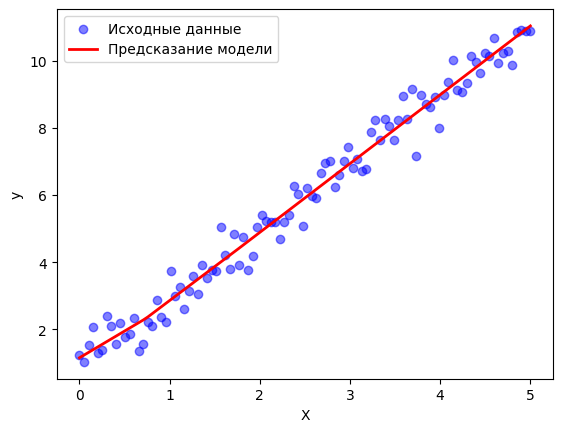

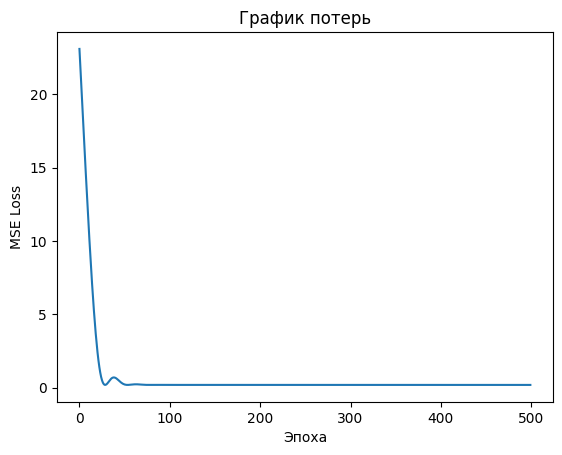

In [37]:
# Предсказания после обучения
with torch.no_grad():
    predicted = model(X_tensor).numpy()

# График данных и предсказаний
plt.scatter(X, y, label='Исходные данные', color='blue', alpha=0.5)
plt.plot(X, predicted, label='Предсказание модели', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# График функции потерь
plt.plot(losses)
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.title('График потерь')
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [39]:
# Генерация данных: y = sin(x) + шум
np.random.seed(42)
X = np.linspace(0, 10, 1000).reshape(-1, 1)
y = np.sin(X) + 0.1 * np.random.randn(1000, 1)

# Разделение на обучение и тест (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Нормализация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Конвертация в тензоры PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [40]:
class RegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 64)  # Входной слой → 64 нейрона
        self.fc2 = nn.Linear(64, 32) # Скрытый слой → 32 нейрона
        self.fc3 = nn.Linear(32, 1)  # Выходной слой → 1 значение
        self.dropout = nn.Dropout(0.2)  # Dropout для регуляризации

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = RegressionNN()

In [41]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [42]:
epochs = 1000
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Обучение
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Тестирование
    model.eval() # Отключает Dropout и BatchNorm
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

Epoch [100/1000], Train Loss: 0.2290, Test Loss: 0.1902
Epoch [200/1000], Train Loss: 0.0591, Test Loss: 0.0269
Epoch [300/1000], Train Loss: 0.0349, Test Loss: 0.0136
Epoch [400/1000], Train Loss: 0.0295, Test Loss: 0.0122
Epoch [500/1000], Train Loss: 0.0277, Test Loss: 0.0112
Epoch [600/1000], Train Loss: 0.0266, Test Loss: 0.0109
Epoch [700/1000], Train Loss: 0.0248, Test Loss: 0.0109
Epoch [800/1000], Train Loss: 0.0252, Test Loss: 0.0115
Epoch [900/1000], Train Loss: 0.0241, Test Loss: 0.0109
Epoch [1000/1000], Train Loss: 0.0237, Test Loss: 0.0105


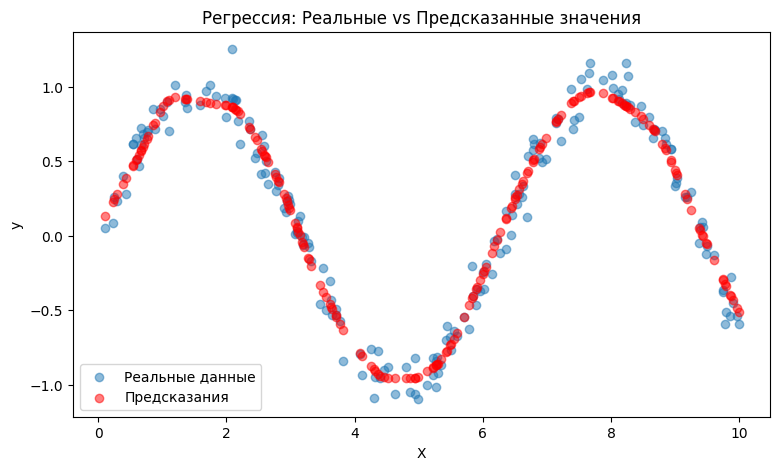

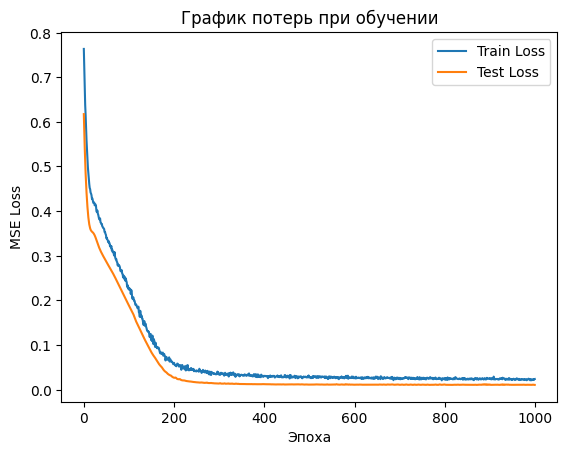

In [43]:
# Предсказания на тестовых данных
with torch.no_grad():
    predicted = model(X_test_tensor).numpy()

# График данных и предсказаний
plt.figure(figsize=(9, 5))
plt.scatter(X_test, y_test, label='Реальные данные', alpha=0.5)
plt.scatter(X_test, predicted, label='Предсказания', color='red', alpha=0.5)
plt.title('Регрессия: Реальные vs Предсказанные значения')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# График потерь
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('График потерь при обучении')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [44]:
import tensorflow

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [46]:
np.random.seed(42)
X = np.linspace(0, 10, 1000).reshape(-1, 1)
y = np.sin(X) + 0.1 * np.random.randn(1000, 1)

# Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Только на train!
X_test_scaled = scaler.transform(X_test)        # Применяем те же параметры

In [48]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(1,)),  # Первый слой
    Dropout(0.2),                                   # Dropout для регуляризации
    Dense(32, activation='relu'),                   # Второй слой
    Dense(1)                                        # Выходной слой (регрессия)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',                                     # MSE для регрессии
    metrics=['mae']                                 # Дополнительная метрика
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=150, # 1000
    batch_size=32,
    validation_data=(X_test_scaled, y_test)
#    verbose=0  # Убрать вывод для краткости
)

Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4769 - mae: 0.6109 - val_loss: 0.3168 - val_mae: 0.4659
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3561 - mae: 0.5137 - val_loss: 0.2842 - val_mae: 0.4464
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3094 - mae: 0.4869 - val_loss: 0.2558 - val_mae: 0.4216
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2954 - mae: 0.4752 - val_loss: 0.2329 - val_mae: 0.4051
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2756 - mae: 0.4621 - val_loss: 0.2112 - val_mae: 0.3790
Epoch 6/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2532 - mae: 0.4352 - val_loss: 0.1921 - val_mae: 0.3592
Epoch 7/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2377 - mae: 0.4183 - val_loss: 0.1741 - val_mae: 0.3344
Epoch 8/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1919 - mae: 0.3689 - val_loss: 0.1561 - val_mae: 0.3120
Epoch 9/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.19

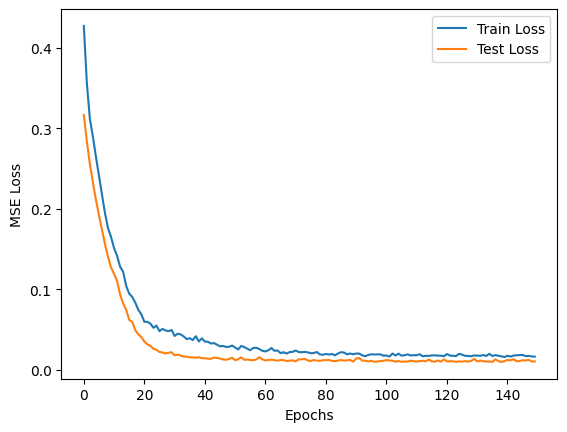

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


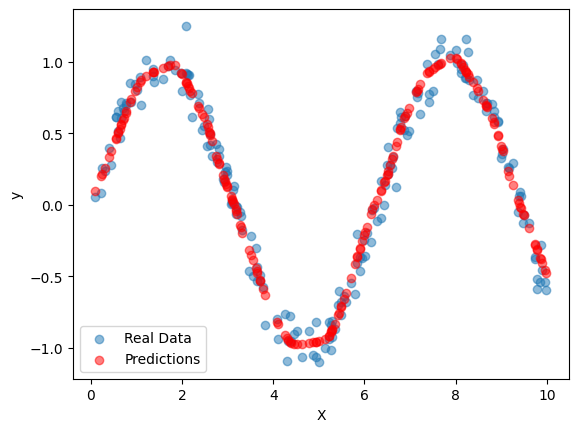

In [50]:
# График потерь
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# Предсказания
y_pred = model.predict(X_test_scaled)

# График данных и предсказаний
plt.scatter(X_test, y_test, label='Real Data', alpha=0.5)
plt.scatter(X_test, y_pred, label='Predictions', color='red', alpha=0.5)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

**Все представленные материалы взяты из открытых источников в интернете плюс искусственный интеллект.**